<a href="https://colab.research.google.com/github/hemanthsaigude/CN7030/blob/main/week5_assemble_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pyspark

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StringIndexer
from pyspark.ml.classification import DecisionTreeClassifier, LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

Mounted at /content/drive


In [ ]:
# Initialize Spark session
spark = SparkSession.builder \
    .appName("Logistic Regression") \
    .getOrCreate()

In [ ]:
dff = spark.read.csv('/content/customer_segmentation_dataset.csv',inferSchema=True, header =True)

In [ ]:
dff.show()


+---+-------------+--------------+-----------------+-------------------+----------------+
|age|annual_income|spending_score|years_as_customer|number_of_purchases|customer_segment|
+---+-------------+--------------+-----------------+-------------------+----------------+
| 22|       113441|            19|                2|                 44|       Low Value|
| 47|        85415|            74|                7|                 11|    Medium Value|
| 60|        78075|            18|               19|                 37|       Low Value|
| 44|        89388|            84|               10|                 15|      High Value|
| 37|        94910|            85|               15|                 31|      High Value|
| 29|        83134|            64|               12|                  8|    Medium Value|
| 46|        52488|            81|               14|                 39|      High Value|
| 50|        90449|            22|               15|                  8|       Low Value|
| 68|     

In [ ]:
dff.select("customer_segment").distinct().show()
dff.printSchema()


+----------------+
|customer_segment|
+----------------+
|    Medium Value|
|      High Value|
|       Low Value|
+----------------+

root
 |-- age: integer (nullable = true)
 |-- annual_income: integer (nullable = true)
 |-- spending_score: integer (nullable = true)
 |-- years_as_customer: integer (nullable = true)
 |-- number_of_purchases: integer (nullable = true)
 |-- customer_segment: string (nullable = true)



In [ ]:
print("Medium Value",dff.select("customer_segment").where("customer_segment=='Medium Value'").count())
print("High Value",dff.select("customer_segment").where("customer_segment=='High Value'").count())
print("Low Value",dff.select("customer_segment").where("customer_segment=='Low Value'").count())


Medium Value 505248
High Value 485871
Low Value 1008881


In [ ]:
[print("column name",dff[t[0]].name,dff.select(t[0]).distinct().show()) for t in dff.dtypes if t[1]=='string' ]

+----------------+
|customer_segment|
+----------------+
|    Medium Value|
|      High Value|
|       Low Value|
+----------------+

column name <bound method Column.name of Column<'customer_segment'>> None


[None]

In [ ]:
numeric_features = [t[0] for t in dff.dtypes if t[1] == 'int']
dff.select(numeric_features).describe().toPandas().transpose()

,0,1,2,3,4
summary,count,mean,stddev,min,max
age,2000000,43.477824,15.00015569010386,18,69
annual_income,2000000,85001.7181955,37527.92677419766,20000,149999
spending_score,2000000,50.049344,28.567160870674087,1,99
years_as_customer,2000000,9.987763,5.478078153924148,1,19
number_of_purchases,2000000,25.019448,14.143843812749502,1,49


In [ ]:
print("total records:",dff.count())
[print(col,"Total null values",dff.where(dff[col].isNull()).count()) for col in dff.columns]

total records: 2000000
age Total null values 0
annual_income Total null values 0
spending_score Total null values 0
years_as_customer Total null values 0
number_of_purchases Total null values 0
customer_segment Total null values 0


[None, None, None, None, None, None]

In [ ]:
df = dff.select('age','annual_income','spending_score','years_as_customer','number_of_purchases','customer_segment')
cols = df.columns
df.printSchema()

root
 |-- age: integer (nullable = true)
 |-- annual_income: integer (nullable = true)
 |-- spending_score: integer (nullable = true)
 |-- years_as_customer: integer (nullable = true)
 |-- number_of_purchases: integer (nullable = true)
 |-- customer_segment: string (nullable = true)



In [ ]:
label_indexer = StringIndexer(inputCol='customer_segment', outputCol='label')

In [ ]:
feature_cols = [col for col in df.columns if col != 'customer_segment']
assembler = VectorAssembler(inputCols=feature_cols, outputCol='features')

In [ ]:
from pyspark.ml import Pipeline
pipeline = Pipeline(stages=[label_indexer, assembler])
pipelineModel = pipeline.fit(df)
df_transformed = pipelineModel.transform(df)
df_transformed.select('features', 'label').show(12, truncate=False)

+-----------------------------+-----+
|features                     |label|
+-----------------------------+-----+
|[22.0,113441.0,19.0,2.0,44.0]|0.0  |
|[47.0,85415.0,74.0,7.0,11.0] |1.0  |
|[60.0,78075.0,18.0,19.0,37.0]|0.0  |
|[44.0,89388.0,84.0,10.0,15.0]|2.0  |
|[37.0,94910.0,85.0,15.0,31.0]|2.0  |
|[29.0,83134.0,64.0,12.0,8.0] |1.0  |
|[46.0,52488.0,81.0,14.0,39.0]|2.0  |
|[50.0,90449.0,22.0,15.0,8.0] |0.0  |
|[68.0,32563.0,99.0,13.0,42.0]|2.0  |
|[67.0,117849.0,1.0,15.0,8.0] |0.0  |
|[30.0,37019.0,70.0,16.0,42.0]|1.0  |
|[56.0,123133.0,21.0,4.0,16.0]|0.0  |
+-----------------------------+-----+
only showing top 12 rows


In [ ]:
print(df_transformed.select("features").show(1))
print(cols)

+--------------------+
|            features|
+--------------------+
|[22.0,113441.0,19...|
+--------------------+
only showing top 1 row
None
['age', 'annual_income', 'spending_score', 'years_as_customer', 'number_of_purchases', 'customer_segment']


In [ ]:
train_data, test_data = df_transformed.randomSplit([0.8, 0.2], seed=42)
print("Training Dataset Count: " + str(train_data.count()))
print("Test Dataset Count: " + str(test_data.count()))

Training Dataset Count: 1600297
Test Dataset Count: 399703


In [ ]:
lr = LogisticRegression(featuresCol='features', labelCol='label')
lr_model = lr.fit(train_data)

In [ ]:
predictions = lr_model.transform(test_data)
predictions.select('features', 'label', 'prediction', 'probability').show(10)

In [ ]:
evaluator = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='accuracy')
accuracy = evaluator.evaluate(predictions)
print("Test Accuracy = %g" % accuracy)


In [ ]:
# Optional: other metrics
evaluator.setMetricName('f1')
f1_score = evaluator.evaluate(predictions)
print("Test F1 Score = %g" % f1_score)


In [ ]:
print(df_transformed.select("features").show(1))
print(cols)

In [ ]:
selectedCols = ['label', 'features'] + cols
dfSelected = df_transformed.select(selectedCols)
dfSelected.printSchema()

In [ ]:
from pyspark.ml.classification import OneVsRest
from pyspark.ml.classification import LogisticRegression

# Define dfSelected which was missing
selectedCols = ['label', 'features'] + cols
dfSelected = df_transformed.select(selectedCols)

train, test = dfSelected.randomSplit([0.7, 0.3], seed = 2018)
lr = LogisticRegression(maxIter=100, \

                        featuresCol="features", \

                        labelCol='label')
ovr = OneVsRest(classifier=lr, \
                labelCol='label', \
                featuresCol='features')

In [ ]:
ovrModel = ovr.fit(train)
predictionsovr = ovrModel.transform(test)
predictionsovr.show(10)

+-----+--------------------+---+-------------+--------------+-----------------+-------------------+----------------+--------------------+----------+
|label|            features|age|annual_income|spending_score|years_as_customer|number_of_purchases|customer_segment|       rawPrediction|prediction|
+-----+--------------------+---+-------------+--------------+-----------------+-------------------+----------------+--------------------+----------+
|  0.0|[18.0,20000.0,5.0...| 18|        20000|             5|               14|                 15|       Low Value|[1248.49664397322...|       0.0|
|  0.0|[18.0,20077.0,38....| 18|        20077|            38|               12|                 41|       Low Value|[342.738883510385...|       0.0|
|  0.0|[18.0,20090.0,40....| 18|        20090|            40|                4|                 38|       Low Value|[287.84267756083,...|       0.0|
|  0.0|[18.0,20120.0,37....| 18|        20120|            37|                8|                  2|       

In [ ]:
from pyspark.mllib.evaluation import MulticlassMetrics
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
prediction_and_labels = predictionsovr.select("prediction", "label") \
    .withColumnRenamed("indexedLabel", "label") \
    .toPandas()
confusion_matrix = pd.crosstab(prediction_and_labels['label'], prediction_and_labels['prediction'], rownames=['Actual'], colnames=['Predicted'])

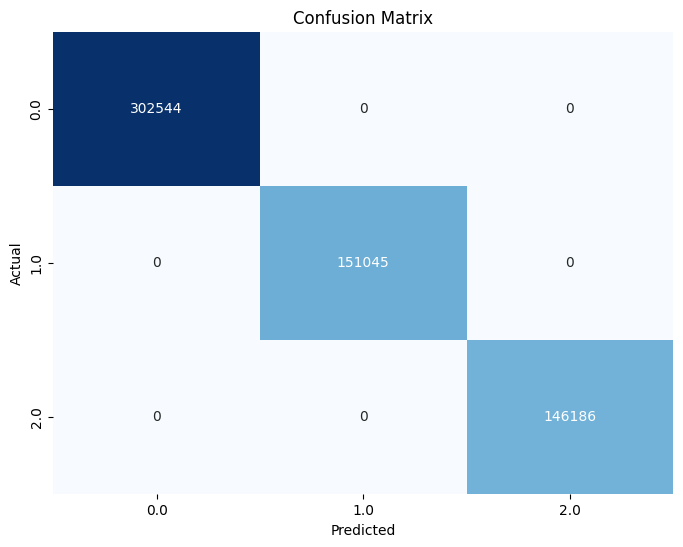

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
evaluator = MulticlassClassificationEvaluator(\
labelCol="label", predictionCol="prediction",\
metricName="accuracy")
accuracy = evaluator.evaluate(predictionsovr)
print("Test accuracy =  " , accuracy)

Test accuracy =   1.0


In [ ]:
from pyspark.ml.classification import DecisionTreeClassifier
train, test = dfSelected.randomSplit([0.7, 0.3], seed = 2018)
print("Training Dataset Count: " + str(train.count()))
print("Test Dataset Count: " + str(test.count()))
dt = DecisionTreeClassifier(featuresCol = 'features', labelCol = 'label', maxDepth = 3)
dtModel = dt.fit(train)
predictions = dtModel.transform(test)

Training Dataset Count: 1400225
Test Dataset Count: 599775


In [ ]:
predictions.select('age', 'annual_income', 'label', 'rawPrediction', 'prediction', 'probability').show(10)
print("Total Actual Positive",predictions.select("label").where('label == 1.0').count())
print("Total Actual Negative",predictions.select("label").where('label == 0.0').count())
pr = predictions.toPandas()
TruePositive =0
FalsePositive=0
TrueNegative=0
FalseNegative=0
Postive=1.0
Negative=0.0
pos=0
Neg=0

+---+-------------+-----+------------------+----------+-------------+
|age|annual_income|label|     rawPrediction|prediction|  probability|
+---+-------------+-----+------------------+----------+-------------+
| 18|        20000|  0.0|[692120.0,0.0,0.0]|       0.0|[1.0,0.0,0.0]|
| 18|        20077|  0.0|[692120.0,0.0,0.0]|       0.0|[1.0,0.0,0.0]|
| 18|        20090|  0.0|[692120.0,0.0,0.0]|       0.0|[1.0,0.0,0.0]|
| 18|        20120|  0.0|[692120.0,0.0,0.0]|       0.0|[1.0,0.0,0.0]|
| 18|        20238|  0.0|[692120.0,0.0,0.0]|       0.0|[1.0,0.0,0.0]|
| 18|        20339|  0.0|[692120.0,0.0,0.0]|       0.0|[1.0,0.0,0.0]|
| 18|        20402|  0.0|[692120.0,0.0,0.0]|       0.0|[1.0,0.0,0.0]|
| 18|        20492|  0.0|[692120.0,0.0,0.0]|       0.0|[1.0,0.0,0.0]|
| 18|        20500|  0.0|[692120.0,0.0,0.0]|       0.0|[1.0,0.0,0.0]|
| 18|        20508|  0.0|[692120.0,0.0,0.0]|       0.0|[1.0,0.0,0.0]|
+---+-------------+-----+------------------+----------+-------------+
only showing top 10 

In [ ]:
print("Total",len(pr["label"]))
for lbl in range(len(pr["label"])):
  if  pr["prediction"][lbl]==Postive:
    pos+=1
    if pr["prediction"][lbl]==pr["label"][lbl]:
      TruePositive+=1
    else:
      FalsePositive+=1
  if  pr["prediction"][lbl]==Negative:
    Neg+=1
    if pr["prediction"][lbl]==pr["label"][lbl]:
      TrueNegative+=1
    else:
      FalseNegative+=1
print("Total Positive & Negative in Prediction. Pos: ",pos,",Neg",Neg)
print("TruePostive",TruePositive,"FalsePostive",FalsePositive)
print("TrueNegative",TrueNegative,"FalseNegative",FalseNegative)

Total 599775
Total Positive & Negative in Prediction. Pos:  157055 ,Neg 296534
TruePostive 151045 FalsePostive 6010
TrueNegative 296534 FalseNegative 0


In [ ]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
evaluator = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='accuracy')

In [ ]:
accuracy = evaluator.evaluate(predictions)
print("Test Accuracy = %g" % accuracy)

Test Accuracy = 0.98998


In [ ]:
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator # Import MulticlassClassificationEvaluator

In [ ]:
rf = RandomForestClassifier(featuresCol='features', labelCol='label', maxDepth = 4,numTrees=20)
train, test = dfSelected.randomSplit([0.7, 0.3], seed = 2018)
rfModel = rf.fit(train)
predictions = rfModel.transform(test)
pr = predictions.toPandas()

In [ ]:
# These counts refer to specific labels (1.0 and 0.0) within the multiclass problem.
# From previous cells, 0.0 = Low Value, 1.0 = Medium Value, 2.0 = High Value.
print("Total Actual Label 1.0 (Medium Value):",predictions.select("label").where('label == 1.0').count())
print("Total Actual Label 0.0 (Low Value):",predictions.select("label").where('label == 0.0').count())
# Note: There is also a label 2.0 (High Value) in this multiclass problem.

Total Actual Label 1.0 (Medium Value): 151045
Total Actual Label 0.0 (Low Value): 302544


In [ ]:
# Evaluate the model using MulticlassClassificationEvaluator
evaluator = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='accuracy')
accuracy = evaluator.evaluate(predictions)
print("Test Accuracy = %g" % accuracy)

Test Accuracy = 0.979966


In [ ]:
# The manual TP/FP/TN/FN calculation below is not appropriate for a 3-class problem as implemented
# (it assumes binary classification based on 1.0 and 0.0). If per-class metrics are needed,
# MulticlassClassificationEvaluator can provide them (e.g., F1, precision, recall per class).
# Total=len(pr["label"])
# TruePositive =0
# FalsePositive=0
# TrueNegative=0
# FalseNegative=0
# Postive=1.0
# Negative=0.0
# pos=0
# Neg=0
# print("Total",len(pr["label"]))
# for lbl in range(len(pr["label"])):
#   if  pr["prediction"][lbl]==Postive:
#     pos+=1
#     if pr["prediction"][lbl]==pr["label"][lbl]:
#       TruePositive+=1
#     else:
#       FalsePositive+=1
#   if  pr["prediction"][lbl]==Negative:
#     Neg+=1
#     if pr["prediction"][lbl]==pr["label"][lbl]:
#       TrueNegative+=1
#     else:
#       FalseNegative+=1
# print("Total positive & Negative in Predictions, Pos",pos,"Neg",Neg)
# print("TruePostive",TruePositive,"FalsePostive",FalsePositive)
# print("TrueNegative",TrueNegative,"FalseNegative",FalseNegative)